In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/train_balanced.csv')

In [ ]:
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nTarget distribution:")
print(df['Depression'].value_counts())


Dataset shape: (26128, 11)

First few rows:
        Age  Academic Pressure  Study Satisfaction  Sleep Duration  \
0  0.653645           0.621259           -0.694231        0.704569   
1 -0.781415           1.345489           -0.694231        0.704569   
2  0.858654          -0.102972            0.040812       -0.552842   
3  0.038619          -0.102972            0.775856       -0.552842   
4  0.243628          -0.102972           -1.429274       -1.181548   

   Dietary Habits  Have you ever had suicidal thoughts ?  Work/Study Hours  \
0        0.118577                               0.761611         -1.121530   
1       -1.134616                               0.761611         -0.312289   
2       -1.134616                               0.761611         -1.661024   
3        1.371770                               0.761611          1.306193   
4        0.118577                               0.761611          1.306193   

   Financial Stress  Degree_Class 12  Degree_Other  Depression  
0

In [ ]:
X = df.drop('Depression', axis=1)
y = df['Depression']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
svm_model = SVC(kernel='rbf', random_state=42)  # You can try different kernels: 'linear', 'rbf', 'poly'
svm_model.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
y_pred = svm_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nSVM Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


SVM Model Accuracy: 0.8400

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      2613
           1       0.83      0.85      0.84      2613

    accuracy                           0.84      5226
   macro avg       0.84      0.84      0.84      5226
weighted avg       0.84      0.84      0.84      5226



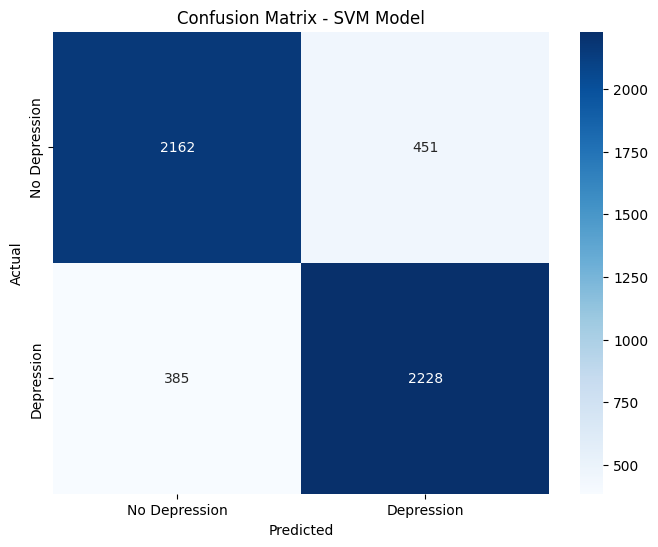

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('Confusion Matrix - SVM Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(svm_model, X, y, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")



Cross-validation scores: [0.84003062 0.84022197 0.84653655 0.83827751 0.84688995]
Mean CV accuracy: 0.8424 (+/- 0.0072)


In [ ]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
for kernel in kernels:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)
    y_pred_kernel = model.predict(X_test)
    accuracy_kernel = accuracy_score(y_test, y_pred_kernel)
    print(f"SVM with {kernel} kernel - Accuracy: {accuracy_kernel:.4f}")

SVM with linear kernel - Accuracy: 0.8398
SVM with rbf kernel - Accuracy: 0.8400
SVM with poly kernel - Accuracy: 0.8339
SVM with sigmoid kernel - Accuracy: 0.7754


In [ ]:
import joblib
joblib.dump(svm_model, 'svm_depression_model.pkl')



['svm_depression_model.pkl']